# Homework Submission - Stage 08: Exploratory Data Analysis

**Goal:** use the official starter's seeded customer-spending dataset to surface data-quality, distributional, relationship, and time-order structure that should guide Stage 09 feature engineering and Stage 10 modeling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.eda import eda_summary

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
rng = np.random.default_rng(8)
ROOT = Path.cwd()
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

## 1. Data and first look

In [2]:
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': rng.choice(['North', 'South', 'East', 'West'], size=n),
    'age': rng.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': rng.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': rng.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions'] * 18 + rng.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)
df.loc[rng.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[rng.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[rng.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max() + 12

df.info()
display(df.head())
display(df.isna().sum().rename('missing_count').to_frame())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[ns]
 1   region        160 non-null    object        
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 7.6+ KB


,date,region,age,income,transactions,spend
0,2021-02-01,East,59.1,45404.01,1,43.59
1,2021-02-02,South,43.4,62858.53,3,181.85
2,2021-02-03,North,50.1,44061.55,1,107.98
3,2021-02-04,West,36.2,31265.07,4,162.59
4,2021-02-05,North,54.5,73833.23,1,142.32


,missing_count
date,0
region,0
age,0
income,5
transactions,0
spend,3


## 2. Numeric and categorical profiles

,count,mean,std,min,25%,50%,75%,max,missing_count,skew,kurtosis
age,160.0,40.090000,8.166546,22.00,34.900,40.40,45.700,59.10,0,0.012457,-0.390759
income,155.0,41858.061419,13293.719991,23403.77,32616.055,38547.19,47762.535,105891.53,5,1.393245,3.187971
transactions,160.0,3.043750,2.432347,0.00,2.000,3.00,4.000,19.00,0,3.620955,21.682680
spend,157.0,112.056815,53.242646,0.00,74.320,114.29,144.340,290.78,3,0.325760,0.111927


Categorical profile: region


,count,proportion
region,,
South,53,0.33125
North,38,0.23750
East,37,0.23125
West,32,0.20000


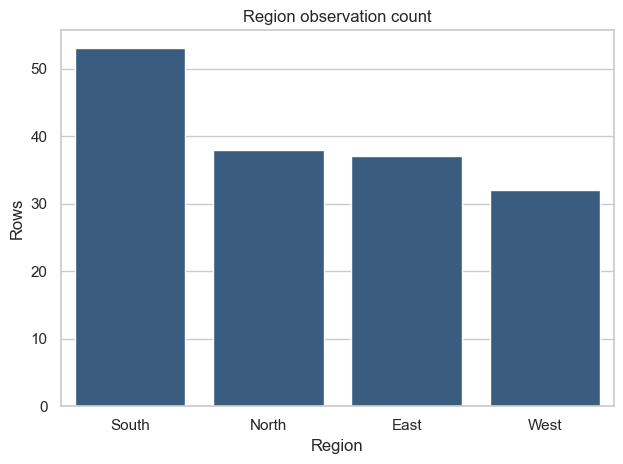

In [3]:
numeric_columns = ['age', 'income', 'transactions', 'spend']
numeric_profile = df[numeric_columns].describe().T
numeric_profile['missing_count'] = df[numeric_columns].isna().sum()
numeric_profile['skew'] = df[numeric_columns].skew()
numeric_profile['kurtosis'] = df[numeric_columns].kurtosis()
display(numeric_profile)

categorical_columns = df.select_dtypes(include=['object', 'category', 'bool']).columns
categorical_profiles = {}
for column in categorical_columns:
    profile = pd.DataFrame({
        'count': df[column].value_counts(dropna=False),
        'proportion': df[column].value_counts(dropna=False, normalize=True),
    })
    categorical_profiles[column] = profile
    print(f'Categorical profile: {column}')
    display(profile)

sns.countplot(data=df, x='region', order=df['region'].value_counts().index, color='#2F5D8A')
plt.title('Region observation count')
plt.xlabel('Region')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

## 3. Distributional views

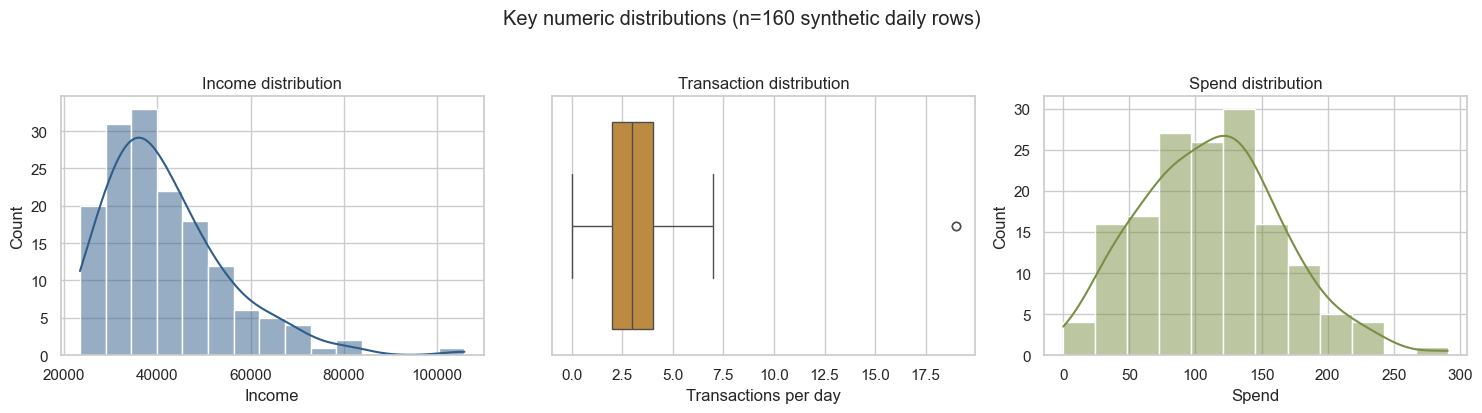

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['income'], kde=True, ax=axes[0], color='#2F5D8A')
axes[0].set_title('Income distribution')
axes[0].set_xlabel('Income')
sns.boxplot(x=df['transactions'], ax=axes[1], color='#D28E2D')
axes[1].set_title('Transaction distribution')
axes[1].set_xlabel('Transactions per day')
sns.histplot(df['spend'], kde=True, ax=axes[2], color='#7A8F45')
axes[2].set_title('Spend distribution')
axes[2].set_xlabel('Spend')
fig.suptitle('Key numeric distributions (n=160 synthetic daily rows)', y=1.03)
fig.tight_layout()
fig.savefig(FIGURES / 'distribution_profile.png', dpi=180, bbox_inches='tight')
plt.show()

Income is right-skewed by construction, so a log transform is a sensible Stage 09 candidate. The transaction boxplot exposes two injected extremes; they should be flagged and stress-tested rather than automatically deleted. Spend inherits variation from both income and transactions plus noise.

## 4. Bivariate relationships

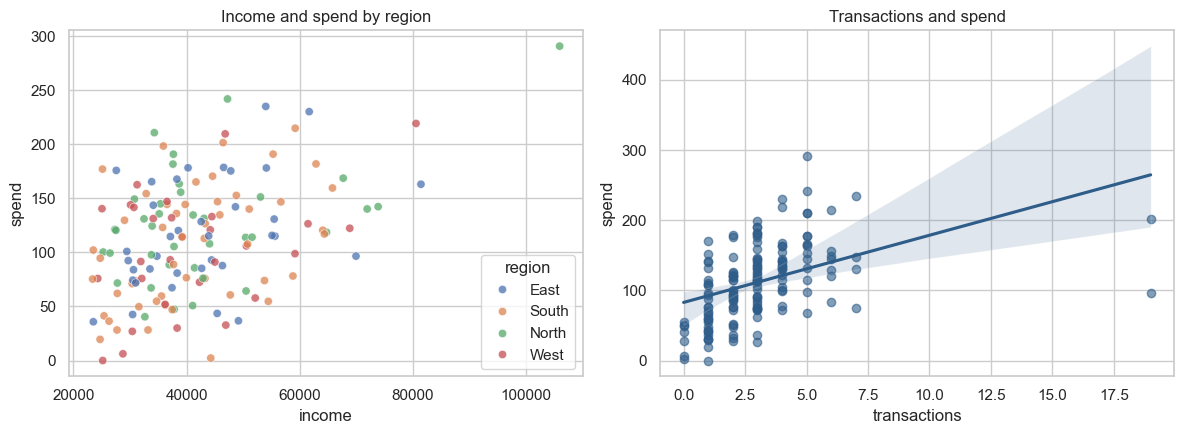

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=df, x='income', y='spend', hue='region', ax=axes[0], alpha=0.75)
axes[0].set_title('Income and spend by region')
sns.regplot(data=df, x='transactions', y='spend', ax=axes[1], scatter_kws={'alpha': 0.6}, color='#2F5D8A')
axes[1].set_title('Transactions and spend')
fig.tight_layout()
fig.savefig(FIGURES / 'bivariate_relationships.png', dpi=180, bbox_inches='tight')
plt.show()

Transactions have the clearest positive association with spend, which is expected from the synthetic formula and is not causal evidence. Income has a weaker positive relationship and substantial vertical spread. Region is useful for checking heterogeneity, but the plot does not show a strong separated cluster.

## 5. Time structure and date gaps

Missing calendar dates: 0


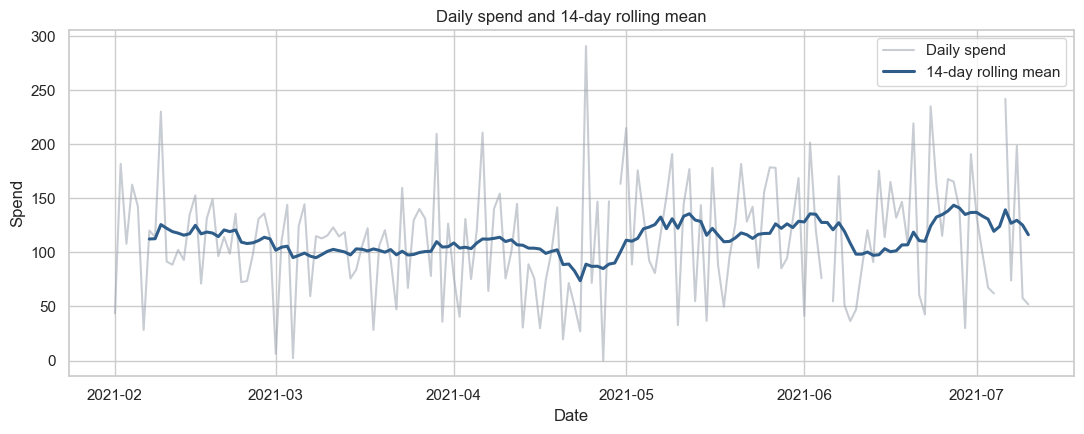

In [6]:
time_df = df.sort_values('date').set_index('date')
expected_dates = pd.date_range(time_df.index.min(), time_df.index.max(), freq='D')
missing_dates = expected_dates.difference(time_df.index)
assert time_df.index.is_monotonic_increasing
print('Missing calendar dates:', len(missing_dates))

daily_spend = time_df['spend']
rolling_spend = daily_spend.rolling(14, min_periods=7).mean()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(daily_spend.index, daily_spend, color='#9CA3AF', alpha=0.55, label='Daily spend')
ax.plot(rolling_spend.index, rolling_spend, color='#2F5D8A', linewidth=2.2, label='14-day rolling mean')
ax.set_title('Daily spend and 14-day rolling mean')
ax.set_xlabel('Date')
ax.set_ylabel('Spend')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'spend_over_time.png', dpi=180, bbox_inches='tight')
plt.show()

There are no date gaps and rows are in chronological order. The 14-day mean fluctuates around a broadly stable level; the generator contains no designed trend or seasonal cycle. Stage 09 may still test lagged rolling context, but Stage 10b should not assume strong predictable time structure.

## 6. Correlation and reusable helper

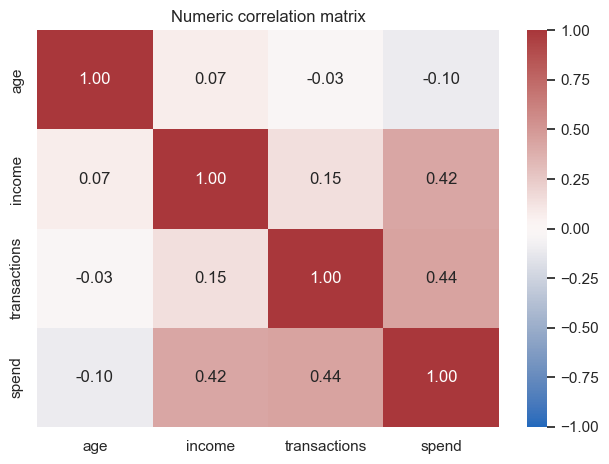

Shape: (160, 6)


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate,nunique,skew,kurtosis
age,160.0,40.090000,8.166546,22.00,34.900,40.40,45.700,59.10,0,0.00000,122,0.012457,-0.390759
income,155.0,41858.061419,13293.719991,23403.77,32616.055,38547.19,47762.535,105891.53,5,0.03125,155,1.393245,3.187971
transactions,160.0,3.043750,2.432347,0.00,2.000,3.00,4.000,19.00,0,0.00000,9,3.620955,21.682680
spend,157.0,112.056815,53.242646,0.00,74.320,114.29,144.340,290.78,3,0.01875,157,0.325760,0.111927


,nunique,missing_count,top_value,top_count,top_share
column,,,,,
region,4,0,South,53,0.33125


,column,issue,value
0,income,high_missingness,0.03125


In [7]:
correlation = df[numeric_columns].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Numeric correlation matrix')
plt.tight_layout()
plt.show()

summary = eda_summary(df, high_missing=0.02, dominance_threshold=0.90)
print('Shape:', summary['shape'])
display(summary['numeric'])
display(summary['categorical'])
display(summary['attention_flags'])

## 7. Top three insights, assumptions, and next steps

1. **Transactions are the strongest modeled driver of spend.** Stage 09 should preserve the same-day count and test leakage-safe lagged/rolling transaction features, while treating the two extremes explicitly.
2. **Income is right-skewed and has five missing values.** Use a median imputation learned on training data and compare an `income_log` feature with the raw scale.
3. **No designed trend or seasonality is visible.** Time order still matters, but rolling features may offer little incremental signal; Stage 10b needs a chronological split and a naive baseline.

**Assumptions and risks:** this is seeded synthetic data designed for workflow practice. Its correlations partly reflect the formula used to generate spend, so they cannot establish real customer behavior or causality. Missingness is injected at random; real missingness may be systematic. Region counts are reasonably balanced, but small category differences should not be overinterpreted.